# Week 2 -- Data Understanding
## Prediksi State of Charge (SOC) Baterai Kendaraan Listrik
**Mata Kuliah:** Proyek Data Mining

## A. Identitas Dataset
| Item | Detail |
|---|---|
| **Nama** | LG 18650HG2 Li-Ion Battery Dataset |
| **Sumber** | McMaster University, Hamilton, Ontario, Canada |
| **Peneliti** | Dr. Phillip Kollmeyer |
| **Topik** | Pengujian performa baterai Li-ion untuk kendaraan listrik pada berbagai suhu dan drive cycle |
| **Alasan Pemilihan** | Dataset berisi profil daya yang dihitung untuk sel tunggal pada kendaraan listrik kompak, dengan variasi suhu (6 level) dan drive cycle standar otomotif (UDDS, HWFET, LA92, US06), cocok untuk prediksi SOC berbasis data mining |

## B. Data Collection
- **Tipe Data:** Eksternal / Public Dataset
- **Cara Perolehan:** Data diunduh dari repositori publik. Eksperimen dilakukan menggunakan Digatron Firing Circuits Universal Battery Tester (75A, 5V) di thermal chamber 8 cu.ft.
- **Sel Baterai:** LG HG2 18650 (3Ah, 3.7V nominal, Li-ion) -- sel baru, digunakan sebagai representasi sel baterai kendaraan listrik kompak
- **Kondisi Pengujian:** 6 suhu (-20°C, -10°C, 0°C, 10°C, 25°C, 40°C), merepresentasikan kondisi operasi kendaraan listrik di berbagai iklim
- **Drive Cycle:** Profil daya dihitung untuk satu sel LG HG2 pada kendaraan listrik kompak, menggunakan standar pengujian otomotif (UDDS, HWFET, LA92, US06)
- **Format:** CSV dan MATLAB (.mat) -- **kami menggunakan CSV**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

BASE_DIR = r'd:\Tugas Kuliah\SEM 6\Proyek Data Mining\Battery'
DATA_DIR = os.path.join(BASE_DIR, 'Data')
NOMINAL_CAPACITY = 3.0  # Ah

## C. Data Description

### C.1 Struktur Folder Dataset

In [2]:
# Menampilkan struktur folder dan jumlah file CSV per suhu
print("=" * 60)
print("STRUKTUR DATASET")
print("=" * 60)

temp_folders = ['n20degC', 'n10degC', '0degC', '10degC', '25degC', '40degC']
temp_labels = ['-20°C', '-10°C', '0°C', '10°C', '25°C', '40°C']

for folder, label in zip(temp_folders, temp_labels):
    path = os.path.join(DATA_DIR, folder)
    if os.path.exists(path):
        csv_files = glob.glob(os.path.join(path, '*.csv'))
        mat_files = glob.glob(os.path.join(path, '*.mat'))
        print(f"  {label:>6s} ({folder:>8s}): {len(csv_files):>2d} CSV, {len(mat_files):>2d} MAT")

STRUKTUR DATASET
   -20°C ( n20degC): 35 CSV, 35 MAT
   -10°C ( n10degC): 38 CSV, 38 MAT
     0°C (   0degC): 32 CSV, 31 MAT
    10°C (  10degC): 32 CSV, 32 MAT
    25°C (  25degC): 36 CSV, 36 MAT
    40°C (  40degC): 35 CSV, 34 MAT


### C.2 Fungsi Pembacaan CSV
CSV memiliki header metadata (~30 baris) sebelum data aktual. Kita perlu skip header tersebut.

In [3]:
def find_header_row(filepath):
    """Cari baris header data (yang mengandung 'Time Stamp,Step,Status')"""
    with open(filepath, 'r', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('Time Stamp,Step,Status'):
                return i
    return None

def load_csv(filepath):
    """Load CSV dengan skip metadata header dan units row"""
    header_row = find_header_row(filepath)
    if header_row is None:
        return None
    # Skip semua baris metadata + baris unit (header_row + 1)
    skip = list(range(header_row)) + [header_row + 1]
    df = pd.read_csv(filepath, skiprows=skip)
    # Hapus kolom kosong di akhir
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    # Bersihkan nama kolom
    df.columns = df.columns.str.strip()
    return df

### C.3 Contoh Data (Sample) -- UDDS 25°C

In [4]:
sample_path = os.path.join(DATA_DIR, '25degC', '551_UDDS.csv')
df_sample = load_csv(sample_path)

print(f"File: 551_UDDS.csv (25°C)")
print(f"Jumlah Baris : {df_sample.shape[0]:,}")
print(f"Jumlah Kolom : {df_sample.shape[1]}")
print()
print("Data Show (5 baris pertama):")
df_sample.head()

File: 551_UDDS.csv (25°C)
Jumlah Baris : 159,646
Jumlah Kolom : 14

Data Show (5 baris pertama):


,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt
0,10/28/2018 5:44:00 PM,25,TABLE,06:40:55.195,00:00:01.335,1,1,LG_HG2_CyclesA,4.18464,-0.05108,23.87099,-0.00000,-0.00001,3.0
1,10/28/2018 5:44:00 PM,25,TABLE,06:40:55.298,00:00:01.438,1,1,LG_HG2_CyclesA,4.18380,-0.08173,23.87099,-0.00000,-0.00002,3.0
2,10/28/2018 5:44:00 PM,25,TABLE,06:40:55.396,00:00:01.536,1,1,LG_HG2_CyclesA,4.18363,-0.08939,23.87099,-0.00001,-0.00003,3.0
3,10/28/2018 5:44:00 PM,25,TABLE,06:40:55.496,00:00:01.636,1,1,LG_HG2_CyclesA,4.18346,-0.09195,23.87099,-0.00001,-0.00004,3.0
4,10/28/2018 5:44:00 PM,25,TABLE,06:40:55.595,00:00:01.735,1,1,LG_HG2_CyclesA,4.18346,-0.09450,23.87099,-0.00001,-0.00005,3.0


In [5]:
print("Data Show (5 baris terakhir):")
df_sample.tail()

Data Show (5 baris terakhir):


,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt
159641,10/28/2018 10:10:05 PM,27,PAU,11:07:00.487,00:09:59.700,0,0,LG_HG2_CyclesA,3.20104,0.0,23.87099,-2.59012,-9.41467,3.0
159642,10/28/2018 10:10:05 PM,27,PAU,11:07:00.588,00:09:59.801,0,0,LG_HG2_CyclesA,3.20104,0.0,23.87099,-2.59012,-9.41467,3.0
159643,10/28/2018 10:10:05 PM,27,PAU,11:07:00.688,00:09:59.901,0,0,LG_HG2_CyclesA,3.20104,0.0,23.87099,-2.59012,-9.41467,3.0
159644,10/28/2018 10:10:05 PM,27,PAU,11:07:00.788,00:10:00.001,0,0,LG_HG2_CyclesA,3.20104,0.0,23.87099,-2.59012,-9.41467,3.0
159645,10/28/2018 10:10:05 PM,27,PAU,11:07:00.792,00:10:00.005,0,0,LG_HG2_CyclesA,3.20104,0.0,23.87099,-2.59012,-9.41467,3.0


### C.4 Atribut Dataset

In [6]:
print("=" * 70)
print("DESKRIPSI ATRIBUT DATASET")
print("=" * 70)

attr_info = {
    'Time Stamp': 'Timestamp pengukuran (MM/DD/YYYY HH:MM:SS)',
    'Step': 'Nomor step dalam program pengujian',
    'Status': 'Status tes (TABLE, PAU, DCH, CHA)',
    'Prog Time': 'Waktu kumulatif program (HH:MM:SS.ms)',
    'Step Time': 'Waktu sejak step dimulai (HH:MM:SS.ms)',
    'Cycle': 'Nomor siklus',
    'Cycle Level': 'Level siklus',
    'Procedure': 'Nama prosedur pengujian',
    'Voltage': '[PENTING] Tegangan terminal sel (V) -- fitur utama prediksi SOC',
    'Current': '[PENTING] Arus pengukuran (A) -- fitur utama prediksi SOC',
    'Temperature': '[PENTING] Suhu casing baterai (degC) -- fitur utama prediksi SOC',
    'Capacity': '[PENTING] Kapasitas terukur / Ah counter (Ah) -- basis perhitungan SOC',
    'WhAccu': 'Akumulasi energi (Wh)',
    'Cnt': 'Counter'
}

for col, desc in attr_info.items():
    dtype = str(df_sample[col].dtype) if col in df_sample.columns else 'N/A'
    print(f"  {col:<15s} | {dtype:<10s} | {desc}")

DESKRIPSI ATRIBUT DATASET
  Time Stamp      | object     | Timestamp pengukuran (MM/DD/YYYY HH:MM:SS)
  Step            | int64      | Nomor step dalam program pengujian
  Status          | object     | Status tes (TABLE, PAU, DCH, CHA)
  Prog Time       | object     | Waktu kumulatif program (HH:MM:SS.ms)
  Step Time       | object     | Waktu sejak step dimulai (HH:MM:SS.ms)
  Cycle           | int64      | Nomor siklus
  Cycle Level     | int64      | Level siklus
  Procedure       | object     | Nama prosedur pengujian
  Voltage         | float64    | [PENTING] Tegangan terminal sel (V) -- fitur utama prediksi SOC
  Current         | float64    | [PENTING] Arus pengukuran (A) -- fitur utama prediksi SOC
  Temperature     | float64    | [PENTING] Suhu casing baterai (degC) -- fitur utama prediksi SOC
  Capacity        | float64    | [PENTING] Kapasitas terukur / Ah counter (Ah) -- basis perhitungan SOC
  WhAccu          | float64    | Akumulasi energi (Wh)
  Cnt             | float6

### C.5 Tipe Data

In [7]:
print("\nTipe Data Per Kolom:")
print(df_sample.dtypes.to_string())


Tipe Data Per Kolom:
Time Stamp      object
Step             int64
Status          object
Prog Time       object
Step Time       object
Cycle            int64
Cycle Level      int64
Procedure       object
Voltage        float64
Current        float64
Temperature    float64
Capacity       float64
WhAccu         float64
Cnt            float64


### C.6 Statistik Deskriptif

In [8]:
numeric_cols = ['Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt']
print("Statistik Deskriptif (Kolom Numerik):")
df_sample[numeric_cols].describe().round(4)

Statistik Deskriptif (Kolom Numerik):


,Voltage,Current,Temperature,Capacity,WhAccu,Cnt
count,159646.0000,159646.0000,159646.0000,159646.0000,159646.0000,159646.0
mean,3.7323,-0.5845,23.9843,-1.2901,-4.8824,3.0
std,0.2652,1.5451,0.1552,0.7572,2.7553,0.0
min,2.9006,-9.1845,23.5555,-2.5901,-9.4147,3.0
25%,3.5450,-1.3613,23.8710,-1.9404,-7.2826,3.0
50%,3.7504,-0.3065,23.9762,-1.2594,-4.8680,3.0
75%,3.9697,0.0000,24.0813,-0.6149,-2.4395,3.0
max,4.2000,5.2794,24.7123,-0.0000,-0.0000,3.0


### C.7 Ringkasan Seluruh Dataset (Semua Suhu, Drive Cycles Saja)

In [9]:
# Load semua drive cycle files untuk ringkasan
drive_cycle_types = ['UDDS', 'HWFET', 'LA92', 'US06', 'Mixed1', 'Mixed2', 'Mixed3', 'Mixed4',
                     'Mixed5', 'Mixed6', 'Mixed7', 'Mixed8']

summary_rows = []
for folder, label in zip(temp_folders, temp_labels):
    path = os.path.join(DATA_DIR, folder)
    csv_files = glob.glob(os.path.join(path, '*.csv'))
    for f in csv_files:
        fname = os.path.basename(f)
        test_type = fname.split('_', 1)[1].replace('.csv', '') if '_' in fname else fname
        # Cek apakah ini drive cycle
        is_drive = any(dc in test_type for dc in drive_cycle_types)
        if is_drive:
            df_temp = load_csv(f)
            if df_temp is not None:
                summary_rows.append({
                    'Temperature': label,
                    'File': fname,
                    'Test_Type': test_type,
                    'Rows': len(df_temp),
                    'V_min': df_temp['Voltage'].min(),
                    'V_max': df_temp['Voltage'].max(),
                    'I_min': df_temp['Current'].min(),
                    'I_max': df_temp['Current'].max(),
                    'T_mean': df_temp['Temperature'].mean()
                })

df_summary = pd.DataFrame(summary_rows)
print(f"Total drive cycle files: {len(df_summary)}")
print(f"Total data points: {df_summary['Rows'].sum():,}")
print()
df_summary.groupby('Temperature').agg(
    Files=('File', 'count'),
    Total_Rows=('Rows', 'sum'),
    V_range=('V_min', lambda x: f"{x.min():.2f} - {df_summary.loc[x.index, 'V_max'].max():.2f}"),
    I_range=('I_min', lambda x: f"{x.min():.2f} - {df_summary.loc[x.index, 'I_max'].max():.2f}"),
    T_mean=('T_mean', 'mean')
).round(2)

Total drive cycle files: 70
Total data points: 4,498,609



,Files,Total_Rows,V_range,I_range,T_mean
Temperature,,,,,
-10°C,12,760603,2.79 - 4.21,-12.13 - 3.08,-8.70
-20°C,12,552049,2.79 - 4.20,-6.28 - 1.60,-18.22
0°C,11,777994,2.79 - 4.20,-18.00 - 3.07,0.37
10°C,11,847086,2.80 - 4.24,-18.10 - 6.00,9.78
25°C,12,927083,2.80 - 4.21,-17.92 - 6.00,24.27
40°C,12,633794,2.81 - 4.21,-17.81 - 6.00,32.58


---
## D. Data Exploration (Visualisasi)

### D.1 Menghitung SOC dari Coulomb Counting
SOC = 1 - (|Ah_discharged| / Nominal_Capacity) × 100%

In [10]:
def add_soc_column(df, nominal_cap=NOMINAL_CAPACITY):
    """Hitung SOC dari kolom Capacity menggunakan Coulomb Counting"""
    df = df.copy()
    df['SOC'] = (1 - (df['Capacity'].abs() / nominal_cap)) * 100
    df['SOC'] = df['SOC'].clip(0, 100)
    return df

df_sample = add_soc_column(df_sample)
print(f"SOC range: {df_sample['SOC'].min():.2f}% - {df_sample['SOC'].max():.2f}%")
df_sample[['Voltage', 'Current', 'Temperature', 'Capacity', 'SOC']].head(10)

SOC range: 13.66% - 100.00%


,Voltage,Current,Temperature,Capacity,SOC
0,4.18464,-0.05108,23.87099,-0.00000,100.000000
1,4.18380,-0.08173,23.87099,-0.00000,100.000000
2,4.18363,-0.08939,23.87099,-0.00001,99.999667
3,4.18346,-0.09195,23.87099,-0.00001,99.999667
4,4.18346,-0.09450,23.87099,-0.00001,99.999667
5,4.18329,-0.09450,23.87099,-0.00001,99.999667
6,4.18329,-0.09706,23.87099,-0.00002,99.999333
7,4.18329,-0.09706,23.87099,-0.00002,99.999333
8,4.18329,-0.09450,23.87099,-0.00002,99.999333
9,4.18329,-0.09706,23.87099,-0.00002,99.999333


### D.2 Distribusi Variabel Utama (UDDS 25°C)

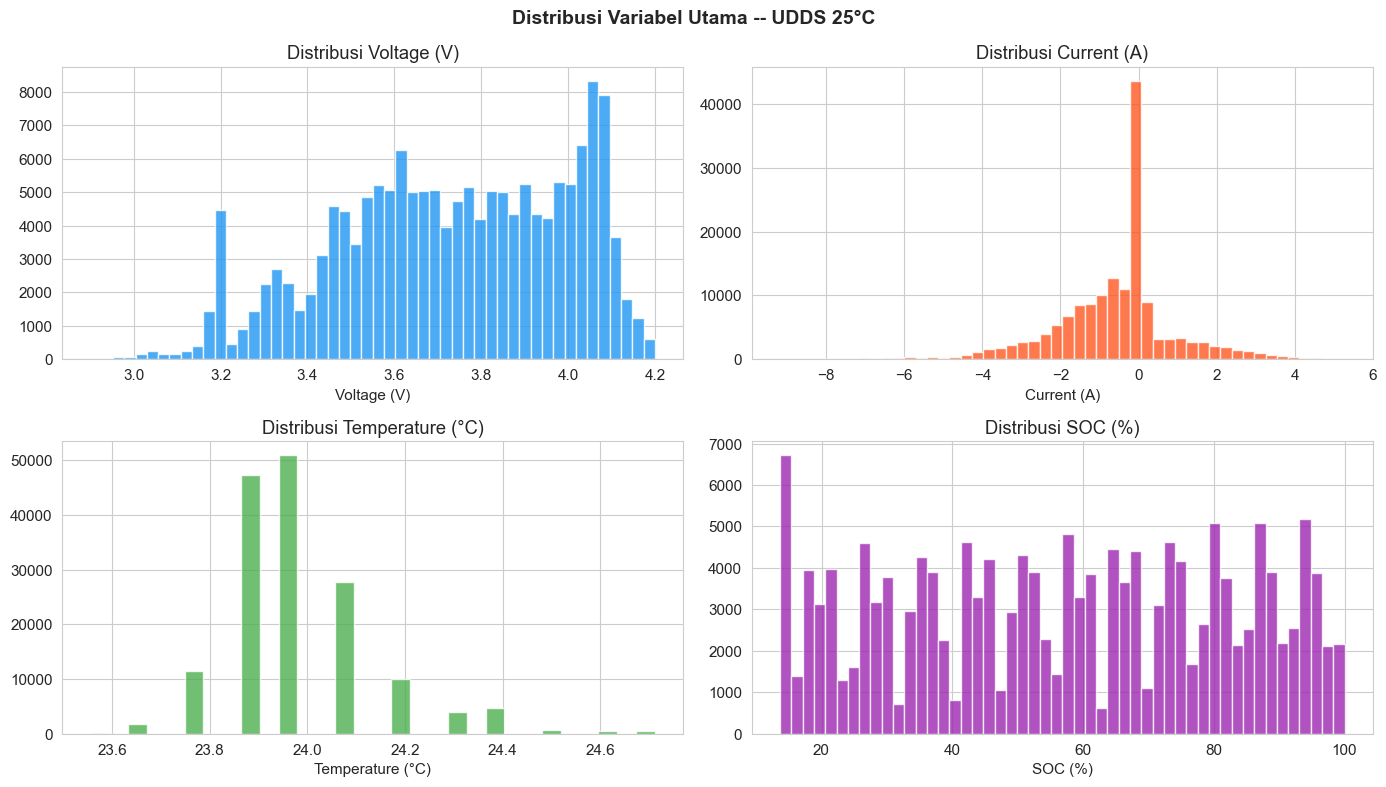

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(df_sample['Voltage'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribusi Voltage (V)')
axes[0, 0].set_xlabel('Voltage (V)')

axes[0, 1].hist(df_sample['Current'], bins=50, color='#FF5722', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Distribusi Current (A)')
axes[0, 1].set_xlabel('Current (A)')

axes[1, 0].hist(df_sample['Temperature'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribusi Temperature (°C)')
axes[1, 0].set_xlabel('Temperature (°C)')

axes[1, 1].hist(df_sample['SOC'], bins=50, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Distribusi SOC (%)')
axes[1, 1].set_xlabel('SOC (%)')

plt.suptitle('Distribusi Variabel Utama -- UDDS 25°C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week2', 'fig_distribusi.png'), dpi=150, bbox_inches='tight')
plt.show()

### D.3 Time Series -- Voltage, Current, SOC vs Waktu

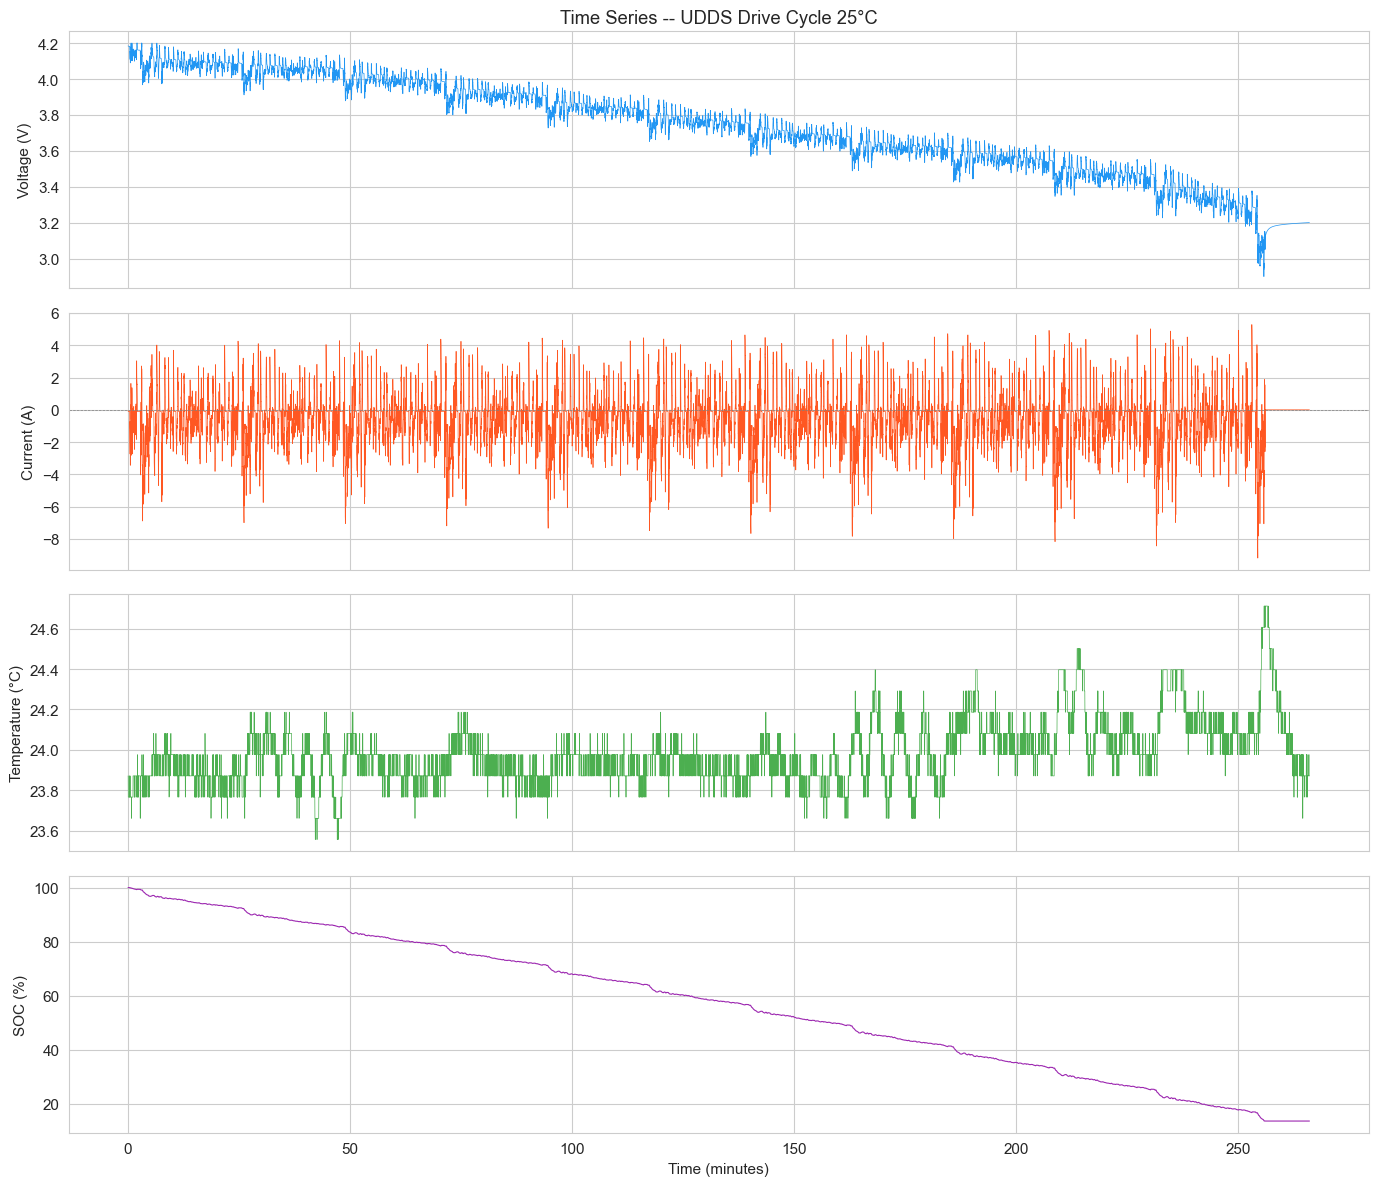

In [12]:
# Buat kolom waktu dalam detik
df_plot = df_sample.copy()
df_plot['Time_s'] = np.arange(len(df_plot)) * 0.1  # sampling ~0.1s
df_plot['Time_min'] = df_plot['Time_s'] / 60

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df_plot['Time_min'], df_plot['Voltage'], color='#2196F3', linewidth=0.5)
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title('Time Series -- UDDS Drive Cycle 25°C')

axes[1].plot(df_plot['Time_min'], df_plot['Current'], color='#FF5722', linewidth=0.5)
axes[1].set_ylabel('Current (A)')
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

axes[2].plot(df_plot['Time_min'], df_plot['Temperature'], color='#4CAF50', linewidth=0.5)
axes[2].set_ylabel('Temperature (°C)')

axes[3].plot(df_plot['Time_min'], df_plot['SOC'], color='#9C27B0', linewidth=0.8)
axes[3].set_ylabel('SOC (%)')
axes[3].set_xlabel('Time (minutes)')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week2', 'fig_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

### D.4 Hubungan Antar Variabel -- Scatter Plot & Correlation

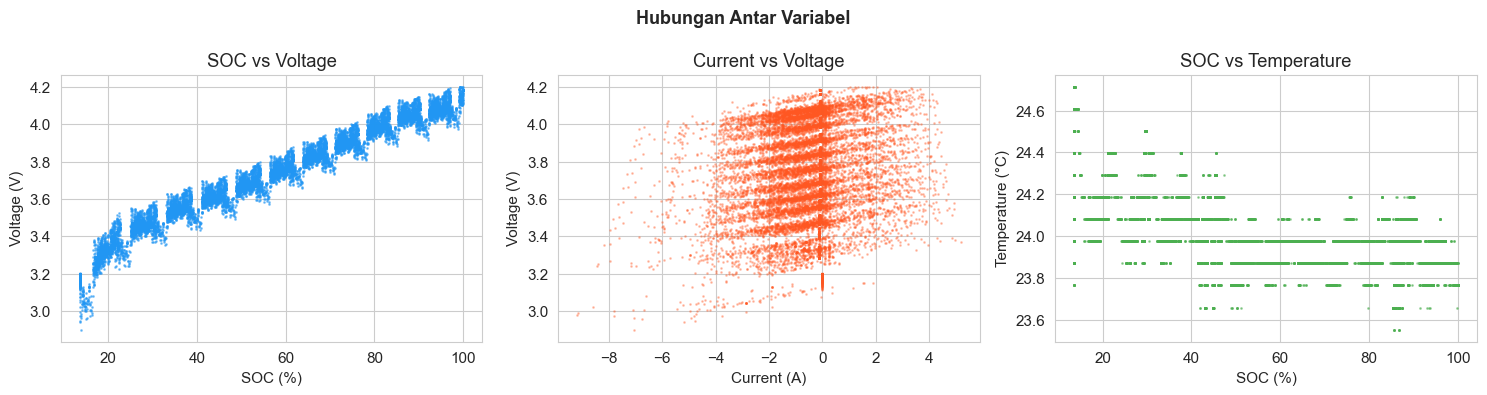

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Subsample untuk scatter yang readable
sub = df_sample.iloc[::10].copy()

axes[0].scatter(sub['SOC'], sub['Voltage'], s=1, alpha=0.5, c='#2196F3')
axes[0].set_xlabel('SOC (%)')
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title('SOC vs Voltage')

axes[1].scatter(sub['Current'], sub['Voltage'], s=1, alpha=0.3, c='#FF5722')
axes[1].set_xlabel('Current (A)')
axes[1].set_ylabel('Voltage (V)')
axes[1].set_title('Current vs Voltage')

axes[2].scatter(sub['SOC'], sub['Temperature'], s=1, alpha=0.5, c='#4CAF50')
axes[2].set_xlabel('SOC (%)')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_title('SOC vs Temperature')

plt.suptitle('Hubungan Antar Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week2', 'fig_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

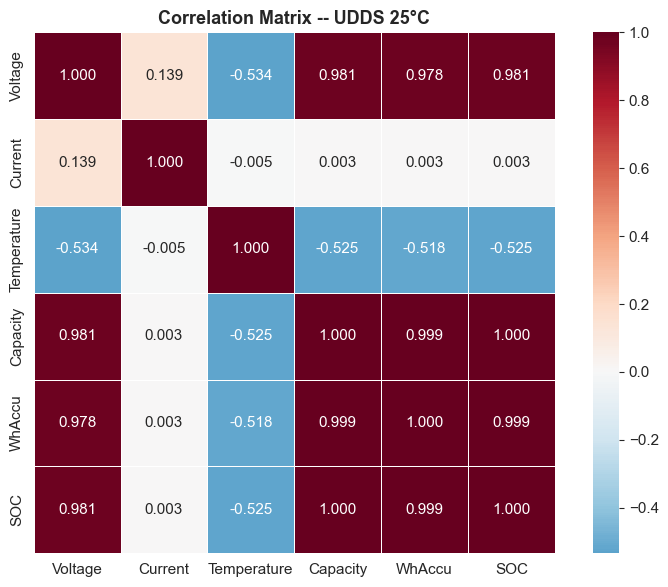

In [14]:
# Correlation Matrix
corr_cols = ['Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'SOC']
corr_matrix = df_sample[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix -- UDDS 25°C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week2', 'fig_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

### D.5 Perbandingan Profil SOC pada Berbagai Suhu

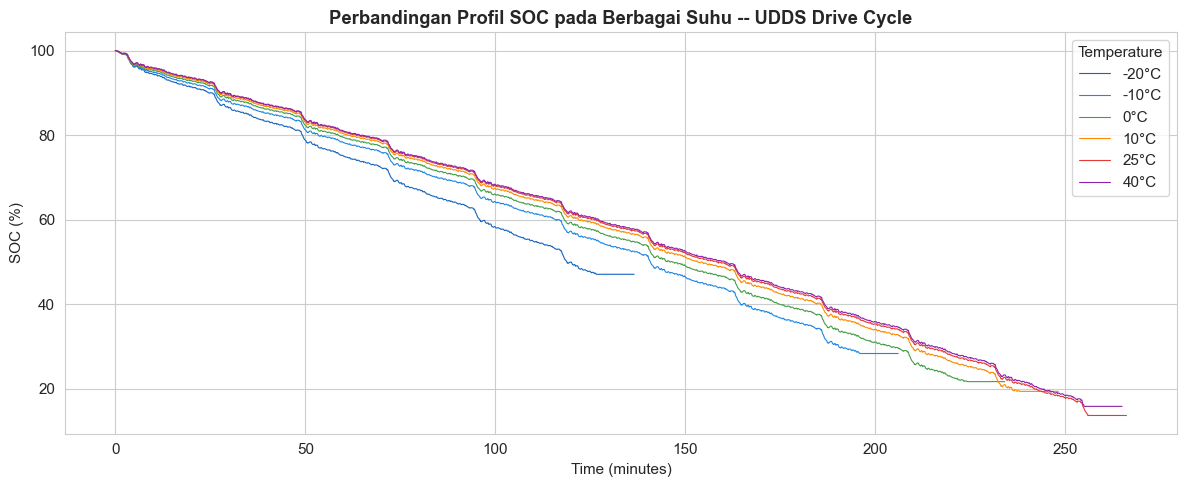

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#1565C0', '#1E88E5', '#43A047', '#FB8C00', '#E53935', '#8E24AA']

for (folder, label), color in zip(zip(temp_folders, temp_labels), colors):
    path = os.path.join(DATA_DIR, folder)
    # Cari file UDDS
    udds_files = [f for f in glob.glob(os.path.join(path, '*.csv')) if 'UDDS' in f]
    if udds_files:
        df_t = load_csv(udds_files[0])
        if df_t is not None:
            df_t = add_soc_column(df_t)
            time_min = np.arange(len(df_t)) * 0.1 / 60
            ax.plot(time_min, df_t['SOC'], label=label, color=color, linewidth=0.8)

ax.set_xlabel('Time (minutes)')
ax.set_ylabel('SOC (%)')
ax.set_title('Perbandingan Profil SOC pada Berbagai Suhu -- UDDS Drive Cycle', fontweight='bold')
ax.legend(title='Temperature')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week2', 'fig_soc_temp.png'), dpi=150, bbox_inches='tight')
plt.show()

### D.6 Insight Awal

1. **Voltage-SOC:** Korelasi positif kuat -- voltage turun seiring SOC menurun, namun hubungannya non-linear (terutama di SOC rendah)
2. **Pengaruh Suhu:** Pada suhu rendah, kapasitas efektif baterai berkurang signifikan, SOC turun lebih cepat
3. **Current Profile:** Drive cycle UDDS memiliki pola arus yang sangat dinamis (urban driving), bervariasi -5A s.d. +2A
4. **Temperature:** Suhu baterai meningkat selama discharge akibat panas internal (self-heating)

---
## E. Data Quality Assessment

In [16]:
print("=" * 60)
print("DATA QUALITY ASSESSMENT -- UDDS 25°C")
print("=" * 60)

# E.1 Missing Values
print("\n E.1 Missing Values:")
missing = df_sample.isnull().sum()
missing_pct = (missing / len(df_sample) * 100).round(4)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
print(missing_df.to_string())
print(f"\nTotal missing values: {missing.sum()}")

DATA QUALITY ASSESSMENT -- UDDS 25°C

 E.1 Missing Values:
             Missing  Percentage (%)
Time Stamp         0             0.0
Step               0             0.0
Status             0             0.0
Prog Time          0             0.0
Step Time          0             0.0
Cycle              0             0.0
Cycle Level        0             0.0
Procedure          0             0.0
Voltage            0             0.0
Current            0             0.0
Temperature        0             0.0
Capacity           0             0.0
WhAccu             0             0.0
Cnt                0             0.0
SOC                0             0.0

Total missing values: 0


In [17]:
# E.2 Data Duplikat
print("\n E.2 Data Duplikat:")
duplicates = df_sample.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates} ({duplicates/len(df_sample)*100:.4f}%)")


 E.2 Data Duplikat:
Jumlah baris duplikat: 0 (0.0000%)


In [18]:
# E.3 Inkonsistensi Format
print("\n E.3 Inkonsistensi Format:")
print(f"Tipe data 'Voltage': {df_sample['Voltage'].dtype} [OK] (numerik)")
print(f"Tipe data 'Current': {df_sample['Current'].dtype} [OK] (numerik)")
print(f"Tipe data 'Temperature': {df_sample['Temperature'].dtype} [OK] (numerik)")
print(f"Tipe data 'Time Stamp': {df_sample['Time Stamp'].dtype} -> perlu konversi ke datetime")

# Cek apakah ada nilai yang tidak wajar
print(f"\nVoltage range: {df_sample['Voltage'].min():.3f}V - {df_sample['Voltage'].max():.3f}V (normal: 2.5-4.2V)")
v_outlier = ((df_sample['Voltage'] < 2.5) | (df_sample['Voltage'] > 4.3)).sum()
print(f"Voltage di luar range normal: {v_outlier} baris")


 E.3 Inkonsistensi Format:
Tipe data 'Voltage': float64 [OK] (numerik)
Tipe data 'Current': float64 [OK] (numerik)
Tipe data 'Temperature': float64 [OK] (numerik)
Tipe data 'Time Stamp': object -> perlu konversi ke datetime

Voltage range: 2.901V - 4.200V (normal: 2.5-4.2V)
Voltage di luar range normal: 0 baris


In [19]:
# E.4 Outlier Detection (IQR Method)
print("\n E.4 Outlier Detection (IQR Method):")

for col in ['Voltage', 'Current', 'Temperature']:
    Q1 = df_sample[col].quantile(0.25)
    Q3 = df_sample[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_sample[col] < lower) | (df_sample[col] > upper)).sum()
    pct = outliers / len(df_sample) * 100
    print(f"  {col:<12s}: {outliers:>6,} outliers ({pct:.2f}%) | Range [{lower:.3f}, {upper:.3f}]")


 E.4 Outlier Detection (IQR Method):
  Voltage     :      5 outliers (0.00%) | Range [2.908, 4.607]
  Current     : 15,299 outliers (9.58%) | Range [-3.403, 2.042]
  Temperature :  6,447 outliers (4.04%) | Range [23.556, 24.397]


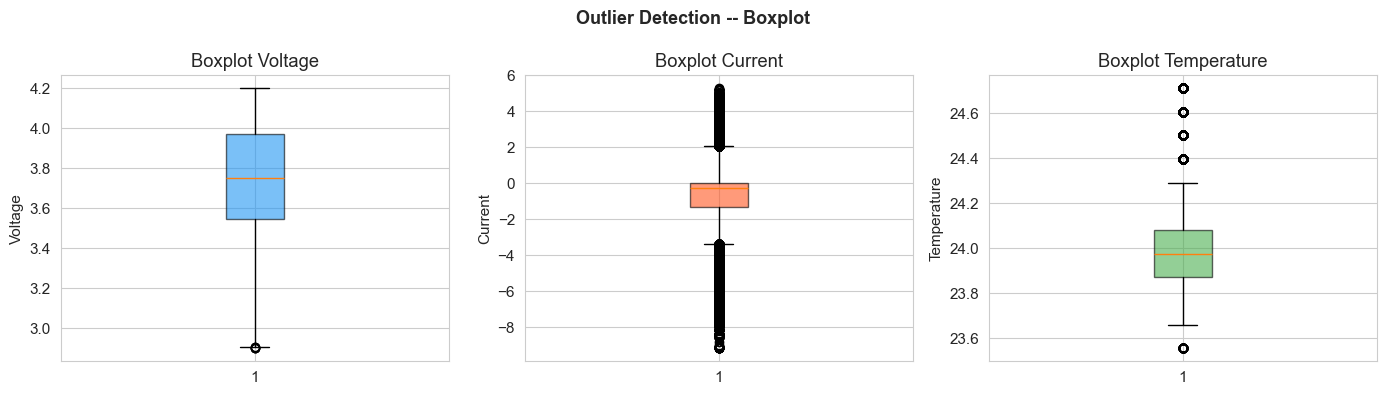

In [20]:
# Boxplot Outlier
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['Voltage', 'Current', 'Temperature'],
                           ['#2196F3', '#FF5722', '#4CAF50']):
    ax.boxplot(df_sample[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f'Boxplot {col}')
    ax.set_ylabel(col)
plt.suptitle('Outlier Detection -- Boxplot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week2', 'fig_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# E.5 Atribut yang Kurang Relevan
print("\n E.5 Analisis Relevansi Atribut:")
relevance = {
    'Time Stamp': ('[!] Sedang', 'Perlu konversi; berguna untuk ordering tapi bukan feature model'),
    'Step': ('[X] Rendah', 'Metadata internal cycler, tidak relevan untuk prediksi SOC'),
    'Status': ('[X] Rendah', 'Status tes (PAU/TABLE/DCH), bukan feature prediktif'),
    'Prog Time': ('[X] Rendah', 'Waktu program kumulatif, redundan dengan Time Stamp'),
    'Step Time': ('[X] Rendah', 'Waktu per step, tidak langsung terkait SOC'),
    'Cycle': ('[X] Rendah', 'Nomor siklus, metadata'),
    'Cycle Level': ('[X] Rendah', 'Level siklus, metadata'),
    'Procedure': ('[X] Rendah', 'Nama prosedur, metadata'),
    'Voltage': ('[OK] Tinggi', 'Korelasi kuat dengan SOC -- PRIMARY FEATURE'),
    'Current': ('[OK] Tinggi', 'Menentukan laju discharge -- PRIMARY FEATURE'),
    'Temperature': ('[OK] Tinggi', 'Mempengaruhi perilaku elektrokimia -- PRIMARY FEATURE'),
    'Capacity': ('[OK] Tinggi', 'Basis perhitungan SOC (target)'),
    'WhAccu': ('[!] Sedang', 'Redundan dengan Capacity; bisa jadi tambahan feature'),
    'Cnt': ('[X] Rendah', 'Counter internal, tidak relevan')
}

for col, (level, reason) in relevance.items():
    print(f"  {col:<15s} | {level:<12s} | {reason}")


 E.5 Analisis Relevansi Atribut:
  Time Stamp      | [!] Sedang   | Perlu konversi; berguna untuk ordering tapi bukan feature model
  Step            | [X] Rendah   | Metadata internal cycler, tidak relevan untuk prediksi SOC
  Status          | [X] Rendah   | Status tes (PAU/TABLE/DCH), bukan feature prediktif
  Prog Time       | [X] Rendah   | Waktu program kumulatif, redundan dengan Time Stamp
  Step Time       | [X] Rendah   | Waktu per step, tidak langsung terkait SOC
  Cycle           | [X] Rendah   | Nomor siklus, metadata
  Cycle Level     | [X] Rendah   | Level siklus, metadata
  Procedure       | [X] Rendah   | Nama prosedur, metadata
  Voltage         | [OK] Tinggi  | Korelasi kuat dengan SOC -- PRIMARY FEATURE
  Current         | [OK] Tinggi  | Menentukan laju discharge -- PRIMARY FEATURE
  Temperature     | [OK] Tinggi  | Mempengaruhi perilaku elektrokimia -- PRIMARY FEATURE
  Capacity        | [OK] Tinggi  | Basis perhitungan SOC (target)
  WhAccu          | [!] Sedang  

### E.6 Ringkasan Data Quality

| Aspek | Temuan | Status |
|---|---|---|
| **Missing Values** | Tidak ada missing values | [OK] Baik |
| **Duplikat** | Minimal / tidak ada | [OK] Baik |
| **Format** | Kolom numerik sudah benar; Timestamp perlu konversi | [!] Minor |
| **Outlier** | Current memiliki outlier wajar (puncak arus saat drive cycle) | [!] Normal |
| **Atribut Tidak Relevan** | 8 dari 14 kolom tidak relevan untuk modeling (metadata) | [*] Perlu filtering |
| **SOC Target** | Tidak tersedia langsung -- perlu dihitung dari Capacity | [*] Perlu engineering |

---
## F. Kesimpulan Data Understanding

1. Dataset berkualitas tinggi (no missing values, format konsisten) dari sumber akademik terpercaya
2. **Important Features untuk prediksi SOC:** Voltage, Current, Temperature
3. **Target (SOC)** harus dihitung melalui Coulomb Counting dari kolom Capacity
4. Data tersedia di 6 kondisi suhu dengan berbagai drive cycle -- memungkinkan model yang robust
5. **Langkah selanjutnya (Data Preparation):** filtering kolom relevan, konversi timestamp, perhitungan SOC, feature engineering (dV/dt, dI/dt), normalisasi